# Session 7 - Classification (Top Price Detection) - Model Comparison (audi_a3_germany)
This notebook introduces **classification** using the Audi A3 Germany dataset. We predict the probability that a listing is a top_price, then compare three simple models.


## 1) What is a classification model in this context?
A **classification model** answers a yes/no question. Here:
- **Input**: car attributes (mileage, age, power, price, fuel type, etc.)
- **Output**: a **probability** that a listing is a top_price
We turn that probability into a decision using a **threshold**:
- If probability >= threshold ? predict **top_price = 1**
- If probability < threshold ? predict **top_price = 0**
This is useful operationally because it helps us prioritize which cars to review first.


## 2) Imports and global configuration

We keep the toolset small and beginner-friendly. All outputs are tagged with the dataset scope.

In [55]:
# Core libraries
# We use pandas for tables, numpy for math, and matplotlib for plots.
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, models, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# BigQuery client
from google.cloud import bigquery

# Global config
RANDOM_SEED = 42
TAG = "audi_a3_germany"
project_id = "albertheadofdata101"
dataset_id = "autoscout_audi_a3_germany"

# Find repo root so we always save in the same place
# This keeps paths stable for students.
def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())
REPORTS_DIR = REPO_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Reports dir:", REPORTS_DIR)

Repo root: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101
Reports dir: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports


## 3) BigQuery connection and quick sanity checks

BigQuery is the **single source of truth**. We start by counting rows in the two tables we need.

In [56]:
# Create a BigQuery client (uses Application Default Credentials)
client = bigquery.Client(project=project_id)

# Helper to run SQL and return a DataFrame
# This keeps notebook code short and readable.
def run_query(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

# Count rows in the source table
sql_count_listings = f"SELECT COUNT(*) AS n\nFROM `{project_id}.{dataset_id}.fact_listings`"

print(f"=== Row counts ({TAG}) ===")
print('fact_listings:')
print(run_query(sql_count_listings))


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


=== Row counts (audi_a3_germany) ===
fact_listings:
      n
0  3380


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 4) Build the modeling dataset
We use `fact_listings` and join `dim_price_label` to get the label.
`top_price = 1` when `price_label = 'top-price'`.


In [57]:
# Build the modeling dataset: top_price label + all listing features
sql_dataset = f"""
SELECT
  fl.*,
  dpl.price_label,
  CASE WHEN dpl.price_label = 'top-price' THEN 1 ELSE 0 END AS top_price
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
WHERE dpl.price_label IS NOT NULL
"""
print(f"=== Loading dataset ({TAG}) ===")
df = run_query(sql_dataset)
print('Loaded rows:', len(df))


=== Loading dataset (audi_a3_germany) ===


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded rows: 3380


## 5) Initial inspection and class balance
We check shape, data types, and class balance. This helps us see if top_prices are rare (they usually are).


In [58]:
# Basic inspection of the dataset
print(f"=== Initial inspection ({TAG}) ===")
print('Shape:', df.shape)
print('Head:')
print(df.head())
print('\nDtypes:')
print(df.dtypes)

# Class balance: how many top_price vs others?
class_counts = df['top_price'].value_counts(dropna=False)
class_perc = (class_counts / len(df) * 100).round(2)
print('\nClass balance (counts):')
print(class_counts)
print('\nClass balance (%):')
print(class_perc)


=== Initial inspection (audi_a3_germany) ===
Shape: (3380, 13)
Head:
   listing_id  model_id  fuel_id  country_id  price_label_id  price_eur  \
0          59         1        1           1               3      26660   
1         199         1        3           1               2      13300   
2         236         1        3           1               2      17120   
3         318         1        3           1               2      23890   
4         447         1        3           1               2      34780   

   mileage_km  power_hp  registration_year  registration_month  age_years  \
0     29875.0     150.0             2022.0                12.0        3.0   
1    147000.0     110.0             2015.0                 3.0       10.0   
2    118920.0     116.0             2019.0                12.0        6.0   
3     73800.0     116.0             2023.0                 6.0        2.0   
4     25095.0     150.0             2024.0                 8.0        1.0   

  price_label  to

## 6) Define X and y
We use a **fixed** feature list to control inputs and avoid leakage.
Features: `price_eur`, `mileage_km`, `age_years`, `fuel_id`, `power_hp`.
We exclude identifiers and label sources:
- `listing_id` (identifier)
- `top_price` (target)
- `price_label` and `price_label_id` (label sources)


In [59]:
# Fixed feature list to avoid leakage
feature_cols = [
    'price_eur',
    'mileage_km',
    'age_years',
    'fuel_id',
    'power_hp',
]

missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required feature columns: {missing}')

# Define target and features
# We keep y as integer 0/1 for metrics.
y = df['top_price'].astype(int)
X = df[feature_cols].copy()

print(f"=== Feature selection ({TAG}) ===")
print('Feature columns:', feature_cols)
print('Final feature count:', X.shape[1])


=== Feature selection (audi_a3_germany) ===
Feature columns: ['price_eur', 'mileage_km', 'age_years', 'fuel_id', 'power_hp']
Final feature count: 5


## 7) Optional validity filters (only if columns exist)

We apply simple data-quality rules if the columns are present.

In [60]:
# Start with all rows kept
mask = pd.Series([True] * len(X))

# Mileage should be positive
if "mileage_km" in X.columns:
    mask &= X["mileage_km"] > 0

# Age should be non-negative
if "age_years" in X.columns:
    mask &= X["age_years"] >= 0

# Apply the filter to X and y
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print(f"=== After validity filters ({TAG}) ===")
print("Rows remaining:", len(X))

=== After validity filters (audi_a3_germany) ===
Rows remaining: 3350


## 8) Preprocessing: numeric vs categorical

We automatically detect column types and apply the same preprocessing to all models:
- **Numeric**: median imputation + standard scaling
- **Categorical**: most-frequent imputation + one-hot encoding

In [61]:
# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in numeric_cols]

print(f"=== Feature types ({TAG}) ===")
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(cat_cols))

# Numeric preprocessing: impute and scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing: impute and one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

=== Feature types (audi_a3_germany) ===
Numeric columns: 5
Categorical columns: 0


## 9) Train/test split (why it matters)

We train on one set and **test on unseen data**. This simulates real-world performance.

In [62]:
# Split once and reuse for all models
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"=== Split sizes ({TAG}) ===")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

=== Split sizes (audi_a3_germany) ===
Train: (2680, 5)
Test: (670, 5)


## 10) The three models (simple explanations)

- **Logistic Regression**: a linear model that maps features to a probability using a sigmoid curve. Coefficients show direction.
- **Random Forest**: many decision trees voting together; captures non-linear patterns.
- **Gradient Boosting**: trees built sequentially to correct mistakes; often strong performance.

In [63]:
# Check class imbalance on the training set
# If top_price listings are rare, we can use class weights for some models.
train_counts = y_train.value_counts()
minority_ratio = train_counts.min() / train_counts.sum()
use_class_weight = minority_ratio < 0.30

print(f"=== Class imbalance check ({TAG}) ===")
print('Minority ratio:', round(minority_ratio, 3))
print('Use class_weight:', use_class_weight)

# Model A: Logistic Regression (baseline)
logreg_params = {
    'max_iter': 2000,
    'solver': 'lbfgs',
}
if use_class_weight:
    logreg_params['class_weight'] = 'balanced'

model_a = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(**logreg_params)),
])

# Model B: Random Forest (non-linear)
rf_params = {
    'n_estimators': 300,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
}
if use_class_weight:
    rf_params['class_weight'] = 'balanced_subsample'

model_b = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(**rf_params)),
])

# Model C: HistGradientBoosting (boosting)
# This estimator has no class_weight; we rely on metrics and thresholding.
model_c = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', HistGradientBoostingClassifier(random_state=RANDOM_SEED)),
])

models = {
    'LogisticRegression': model_a,
    'RandomForest': model_b,
    'HistGradientBoosting': model_c,
}


=== Class imbalance check (audi_a3_germany) ===
Minority ratio: 0.246
Use class_weight: True


## 11) Why accuracy can be misleading
If top_prices are rare, a model that **always predicts ?not a top_price?** can still get high accuracy.
Example: if only 5% are top_prices, predicting ?no? for everything gives 95% accuracy?but finds **zero top_prices**.


## 12) Metrics explained (math intuition + business meaning)
**Confusion matrix terms** (top_price context):
- **TP**: predicted top_price and it is a top_price
- **FP**: predicted top_price but it is NOT a top_price (wasted time)
- **TN**: predicted not top_price and it is not a top_price
- **FN**: predicted not top_price but it IS a top_price (missed opportunity)
**Precision** = TP / (TP + FP)
- ?Among predicted top_prices, how many are real??
- Important if reviewing a car costs time/money.
**Recall** = TP / (TP + FN)
- ?Among real top_prices, how many did we catch??
- Important if missing top_prices is costly.
**F1** = harmonic mean of precision and recall
- Balances the two when both matter.
**ROC-AUC**
- Measures ranking quality across all thresholds.
- Good for comparing models before choosing a threshold.


## 13) Cross-validation on TRAIN only

We use **StratifiedKFold** so each fold keeps the same class balance. This gives us a fair, stable estimate of model performance.

In [64]:
# Cross-validation setup
train_counts = y_train.value_counts()
minority_count = int(train_counts.min()) if len(train_counts) > 0 else 0

if y_train.nunique() < 2 or minority_count < 2:
    print(f"=== CV evaluation ({TAG}) ===")
    print('Not enough positive/negative examples for cross-validation.')
    comparison_cv = pd.DataFrame({
        'model': list(models.keys()),
        'cv_roc_auc_mean': np.nan,
        'cv_roc_auc_std': np.nan,
        'cv_f1_mean': np.nan,
        'cv_f1_std': np.nan,
    })
else:
    n_splits = min(5, minority_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    # Collect CV results
    cv_rows = []

    print(f"=== CV evaluation ({TAG}) ===")
    for name, pipeline in models.items():
        # Compute ROC-AUC and F1 on training folds only
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring={'roc_auc': 'roc_auc', 'f1': 'f1'},
            n_jobs=-1,
        )

        # Store summary statistics
        cv_rows.append({
            'model': name,
            'cv_roc_auc_mean': scores['test_roc_auc'].mean(),
            'cv_roc_auc_std': scores['test_roc_auc'].std(),
            'cv_f1_mean': scores['test_f1'].mean(),
            'cv_f1_std': scores['test_f1'].std(),
        })

        # Print a readable summary
        print(
            f"{name}: ROC-AUC={scores['test_roc_auc'].mean():.3f}+/-{scores['test_roc_auc'].std():.3f}, "
            f"F1={scores['test_f1'].mean():.3f}+/-{scores['test_f1'].std():.3f}"
        )

    comparison_cv = pd.DataFrame(cv_rows)

print('\nCV summary:')
print(comparison_cv)


=== CV evaluation (audi_a3_germany) ===
LogisticRegression: ROC-AUC=0.671+/-0.032, F1=0.456+/-0.013
RandomForest: ROC-AUC=0.777+/-0.013, F1=0.499+/-0.034
HistGradientBoosting: ROC-AUC=0.783+/-0.010, F1=0.516+/-0.043

CV summary:
                  model  cv_roc_auc_mean  cv_roc_auc_std  cv_f1_mean  \
0    LogisticRegression         0.670927        0.032170    0.456343   
1          RandomForest         0.777466        0.012753    0.498958   
2  HistGradientBoosting         0.782596        0.009518    0.515732   

   cv_f1_std  
0   0.013383  
1   0.033946  
2   0.043216  


## 14) Fit on TRAIN and evaluate on TEST

We now train each model on the full training set, then evaluate on the held-out test set.

In [65]:
# Fit and evaluate on the test set

test_rows = []

print(f"=== Test evaluation ({TAG}) ===")
for name, pipeline in models.items():
    # Fit on full training data
    pipeline.fit(X_train, y_train)

    # Predict probabilities and labels using the default 0.5 threshold
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # Compute metrics
    test_rows.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, y_proba),
    })

    print(
        f"{name}: ROC-AUC={test_rows[-1]['test_roc_auc']:.3f}, "
        f"F1={test_rows[-1]['test_f1']:.3f}"
    )

comparison_test = pd.DataFrame(test_rows)
print("\nTest summary:")
print(comparison_test)

=== Test evaluation (audi_a3_germany) ===
LogisticRegression: ROC-AUC=0.696, F1=0.476
RandomForest: ROC-AUC=0.797, F1=0.485
HistGradientBoosting: ROC-AUC=0.785, F1=0.452

Test summary:
                  model  test_accuracy  test_precision  test_recall   test_f1  \
0    LogisticRegression       0.611940        0.356495     0.715152  0.475806   
1          RandomForest       0.791045        0.616822     0.400000  0.485294   
2  HistGradientBoosting       0.768657        0.542373     0.387879  0.452297   

   test_roc_auc  
0      0.696310  
1      0.796898  
2      0.784662  


## 15) Model comparison (how to decide)
We combine CV and test metrics to compare models. There is **no universal best model**.
- If you want fewer false top_prices ? focus on **precision**
- If you want to catch more top_prices ? focus on **recall**
- **ROC-AUC** helps compare ranking quality before choosing a threshold


In [66]:
# Merge CV and test metrics into one table
comparison = comparison_test.merge(comparison_cv, on='model', how='left')

print(f"=== Model comparison ({TAG}) ===")
print(comparison)

# Save to reports
comparison_path = REPORTS_DIR / f"{TAG}_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print('Saved comparison table to:', comparison_path)


=== Model comparison (audi_a3_germany) ===
                  model  test_accuracy  test_precision  test_recall   test_f1  \
0    LogisticRegression       0.611940        0.356495     0.715152  0.475806   
1          RandomForest       0.791045        0.616822     0.400000  0.485294   
2  HistGradientBoosting       0.768657        0.542373     0.387879  0.452297   

   test_roc_auc  cv_roc_auc_mean  cv_roc_auc_std  cv_f1_mean  cv_f1_std  
0      0.696310         0.670927        0.032170    0.456343   0.013383  
1      0.796898         0.777466        0.012753    0.498958   0.033946  
2      0.784662         0.782596        0.009518    0.515732   0.043216  
Saved comparison table to: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_model_comparison.csv


## 16) Confusion matrices (one per model)

These show TP, FP, TN, FN visually for each model using the default threshold.

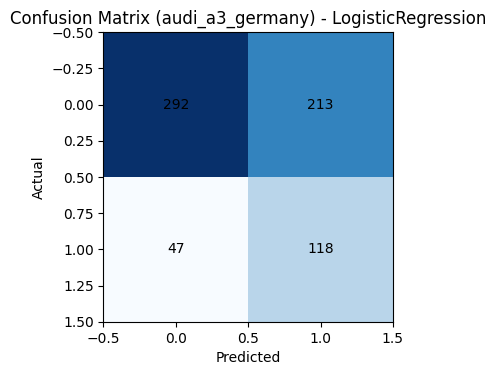

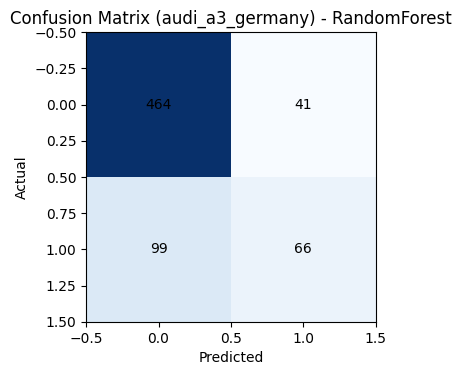

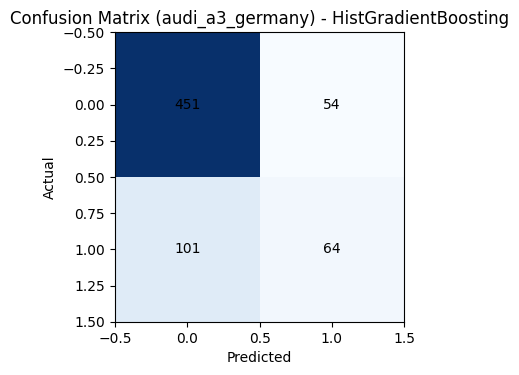

In [67]:
# Plot confusion matrices for each model
confusion_paths = []

for name, pipeline in models.items():
    # Predict labels using the 0.5 threshold
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot the matrix
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix ({TAG}) - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Add counts inside the cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()

    # Save the plot
    file_safe_name = name.replace(" ", "_")
    cm_path = REPORTS_DIR / f"{TAG}_confusion_matrix_{file_safe_name}.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()

    confusion_paths.append(cm_path)

## 17) Threshold tuning (operational strategy)
Lower thresholds ? **more predicted top_prices** (higher recall, lower precision).  
Higher thresholds ? **fewer predicted top_prices** (lower recall, higher precision).
This helps decide how many cars to review each week.


=== Best model (audi_a3_germany) ===
Best model: RandomForest

Threshold table:
    threshold  precision    recall        f1  accuracy
0        0.20   0.430976  0.775758  0.554113  0.692537
1        0.25   0.461538  0.690909  0.553398  0.725373
2        0.30   0.495495  0.666667  0.568475  0.750746
3        0.35   0.500000  0.575758  0.535211  0.753731
4        0.40   0.547771  0.521212  0.534161  0.776119
5        0.45   0.569343  0.472727  0.516556  0.782090
6        0.50   0.616822  0.400000  0.485294  0.791045
7        0.55   0.635294  0.327273  0.432000  0.788060
8        0.60   0.676056  0.290909  0.406780  0.791045
9        0.65   0.766667  0.278788  0.408889  0.801493
10       0.70   0.764706  0.236364  0.361111  0.794030
11       0.75   0.767442  0.200000  0.317308  0.788060
12       0.80   0.787879  0.157576  0.262626  0.782090
Saved threshold table to: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi

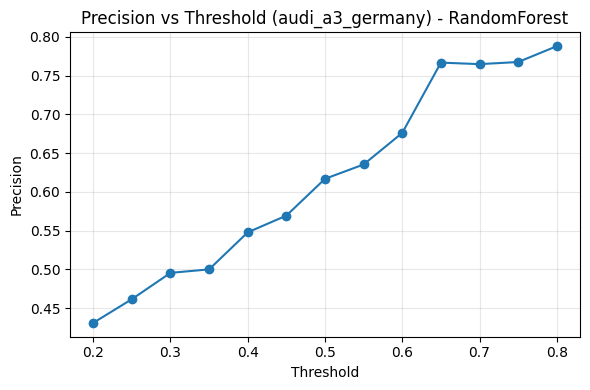

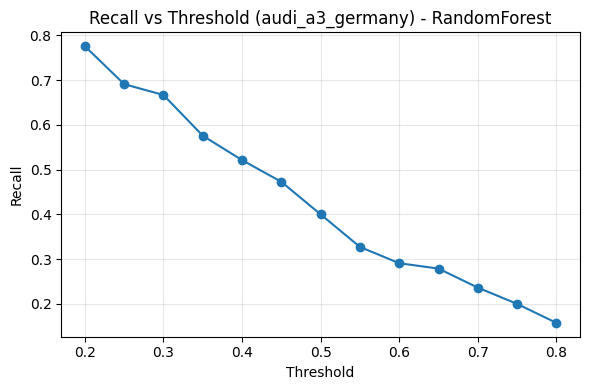

In [68]:
# Pick the best model by test ROC-AUC, tie-break by F1
best_row = comparison.sort_values(
    ["test_roc_auc", "test_f1"], ascending=False
).iloc[0]

best_model_name = best_row["model"]
best_model = models[best_model_name]

print(f"=== Best model ({TAG}) ===")
print("Best model:", best_model_name)

# Compute threshold metrics for the best model
best_proba = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.2, 0.81, 0.05)

rows = []
for t in thresholds:
    preds = (best_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "accuracy": accuracy_score(y_test, preds),
    })

threshold_df = pd.DataFrame(rows)
print("\nThreshold table:")
print(threshold_df)

# Save threshold table
threshold_path = REPORTS_DIR / f"{TAG}_threshold_table_{best_model_name.replace(' ', '_')}.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold table to:", threshold_path)

# Plot precision vs threshold
plt.figure(figsize=(6, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o")
plt.title(f"Precision vs Threshold ({TAG}) - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.tight_layout()

precision_plot_path = REPORTS_DIR / f"{TAG}_precision_threshold_{best_model_name.replace(' ', '_')}.png"
plt.savefig(precision_plot_path, dpi=150)
plt.show()

# Plot recall vs threshold
plt.figure(figsize=(6, 4))
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o")
plt.title(f"Recall vs Threshold ({TAG}) - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.grid(True, alpha=0.3)
plt.tight_layout()

recall_plot_path = REPORTS_DIR / f"{TAG}_recall_threshold_{best_model_name.replace(' ', '_')}.png"
plt.savefig(recall_plot_path, dpi=150)
plt.show()

## 18) Interpretability

Logistic Regression gives coefficients (direction and strength). Random Forest gives feature importances.

In [69]:
# Logistic Regression coefficients
logreg_pipe = models["LogisticRegression"]
preprocessor_fitted = logreg_pipe.named_steps["preprocess"]
clf = logreg_pipe.named_steps["clf"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()
coefs = clf.coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
}).sort_values("coefficient", ascending=False)

# Top positive and negative coefficients
pos_top = coef_df.head(20)
neg_top = coef_df.tail(20)

print(f"=== Logistic Regression coefficients ({TAG}) ===")
print("Top 20 positive:")
print(pos_top)
print("\nTop 20 negative:")
print(neg_top)

# Save coefficients
coef_path = REPORTS_DIR / f"{TAG}_logreg_top_coefficients.csv"
coef_df.to_csv(coef_path, index=False)
print("Saved coefficients to:", coef_path)

=== Logistic Regression coefficients (audi_a3_germany) ===
Top 20 positive:
           feature  coefficient
4    num__power_hp     0.148907
3     num__fuel_id     0.018598
1  num__mileage_km    -0.614717
2   num__age_years    -1.126930
0   num__price_eur    -1.288834

Top 20 negative:
           feature  coefficient
4    num__power_hp     0.148907
3     num__fuel_id     0.018598
1  num__mileage_km    -0.614717
2   num__age_years    -1.126930
0   num__price_eur    -1.288834
Saved coefficients to: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_logreg_top_coefficients.csv


### Random Forest feature importance

Feature importance shows which inputs the forest used most. This is not a causal claim, just a ranking.

In [70]:
# Random Forest feature importance
rf_pipe = models["RandomForest"]
rf_clf = rf_pipe.named_steps["clf"]

# Use the same preprocessor feature names
rf_feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
rf_importances = rf_clf.feature_importances_

rf_imp_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False)

rf_top = rf_imp_df.head(20)
print(f"=== Random Forest importances ({TAG}) ===")
print(rf_top)

rf_imp_path = REPORTS_DIR / f"{TAG}_rf_feature_importance.csv"
rf_imp_df.to_csv(rf_imp_path, index=False)
print("Saved RF importances to:", rf_imp_path)

=== Random Forest importances (audi_a3_germany) ===
           feature  importance
0   num__price_eur    0.382164
1  num__mileage_km    0.356333
2   num__age_years    0.152275
4    num__power_hp    0.072939
3     num__fuel_id    0.036288
Saved RF importances to: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_rf_feature_importance.csv


### HistGradientBoosting limitation note

Scikit-learn does not provide straightforward feature importances for `HistGradientBoostingClassifier`, so we do not report them here.

## 19) Persist results to BigQuery
We overwrite results in BigQuery each run.
- **Per-listing predictions** go to `fact_top_price_predictions`
- **Per-model metrics** go to `model_evaluation_summary`


In [71]:
# Write per-listing predictions to BigQuery (overwrite each run)
print(f"=== Persist predictions to BigQuery ({TAG}) ===")

# Model name mapping required by the BI table schema
model_name_map = {
    'LogisticRegression': 'logistic_regression',
    'RandomForest': 'random_forest',
    'HistGradientBoosting': 'hist_gradient_boosting',
}

# Align listing_id with the filtered feature set
# We use df filtered by X.index to stay consistent with preprocessing.
df_modeling = df.loc[X.index].copy()
if 'listing_id' not in df_modeling.columns:
    raise ValueError('listing_id is required for BigQuery persistence.')

threshold_used = 0.5

pred_rows = []
for name, pipeline in models.items():
    # Predict probabilities for the full dataset
    proba = pipeline.predict_proba(X)[:, 1]

    # Build a prediction DataFrame for this model
    model_df = pd.DataFrame({
        'listing_id': df_modeling['listing_id'].astype('int64'),
        'model_name': model_name_map[name],
        'predicted_proba': proba.astype('float64'),
        'predicted_label': (proba >= threshold_used),
        'threshold_used': float(threshold_used),
    })

    pred_rows.append(model_df)

# Combine all models into one table
predictions_df = pd.concat(pred_rows, ignore_index=True)

pred_table = f"{project_id}.{dataset_id}.fact_top_price_predictions"
client.delete_table(pred_table, not_found_ok=True)
job_config = bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE')

client.load_table_from_dataframe(
    predictions_df,
    pred_table,
    job_config=job_config,
).result()

print('Rows written:', len(predictions_df))
print('Table replaced:', pred_table)


=== Persist predictions to BigQuery (audi_a3_germany) ===


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Rows written: 10050
Table replaced: albertheadofdata101.autoscout_audi_a3_germany.fact_top_price_predictions


In [72]:
# Write model evaluation summary to BigQuery (overwrite each run)
print(f"=== Persist evaluation summary ({TAG}) ===")

# Start from the comparison table
summary_df = comparison.copy()
summary_df = summary_df.rename(columns={
    'model': 'model_name',
    'test_roc_auc': 'roc_auc_test',
    'test_f1': 'f1_test',
    'test_precision': 'precision_test',
    'test_recall': 'recall_test',
    'test_accuracy': 'accuracy_test',
})

# Map model names to schema values
summary_df['model_name'] = summary_df['model_name'].map(model_name_map)

# Add metadata columns
summary_df['threshold_used'] = float(threshold_used)

# Order columns to match expected schema
summary_df = summary_df[[
    'model_name',
    'roc_auc_test',
    'f1_test',
    'precision_test',
    'recall_test',
    'accuracy_test',
    'cv_roc_auc_mean',
    'cv_roc_auc_std',
    'cv_f1_mean',
    'cv_f1_std',
    'threshold_used',
]]

# Overwrite table in BigQuery
eval_table = f"{project_id}.{dataset_id}.model_evaluation_summary"
client.delete_table(eval_table, not_found_ok=True)
job_config = bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE')

client.load_table_from_dataframe(
    summary_df,
    eval_table,
    job_config=job_config,
).result()

print('Rows written:', len(summary_df))
print('Table replaced:', eval_table)


=== Persist evaluation summary (audi_a3_germany) ===


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Rows written: 3
Table replaced: albertheadofdata101.autoscout_audi_a3_germany.model_evaluation_summary


## 20) Final artifacts summary

All saved outputs (CSV and plots) are in `reports/` and tagged with the dataset scope.

In [73]:
# Collect and print saved artifact paths
artifacts = [
    comparison_path,
    *confusion_paths,
    threshold_path,
    precision_plot_path,
    recall_plot_path,
    coef_path,
    rf_imp_path,
]

print(f"=== Saved artifacts ({TAG}) ===")
for p in artifacts:
    print(p)

=== Saved artifacts (audi_a3_germany) ===
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_model_comparison.csv
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_confusion_matrix_LogisticRegression.png
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_confusion_matrix_RandomForest.png
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_confusion_matrix_HistGradientBoosting.png
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\reports\audi_a3_germany_threshold_table_RandomForest.csv
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData

## 21) Homework
- Pick your own make/model/country combination (at least **3000 listings**).
- Ensure `price_label` is available in `fact_listings`, then rerun this notebook end-to-end.
- Compare the three models and **justify** which trade-off (precision vs recall) you prefer for your use case.
